In [26]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

Model 1 fit value: a = 0.5602956224021617, b = 1.624180174188769
Model 2 fit value: a = 0.109029373958477, b = 0.4493040779160805


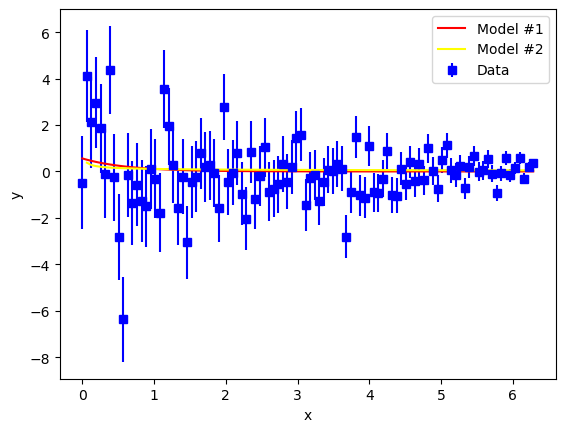

In [27]:
x = np.linspace(0, 2*np.pi, 100)

# Model #1 which returns a*exp(-b*x)
def expModel(x, a, b):
    return a * np.exp(-b * x)

# Model #2 which returns y = a / (x**b)
def powerModel(x, a, b):
    return a / (x**b)

# Parameters
a = 3
b = 4

# Just gonna copy stuff from Session 2, basically adds scatter to the Y value w/ noise. 
y = expModel(x, a, b)
sigma = np.linspace(2, 0.2, 100)
noise = np.random.normal(0, sigma)
yScatterVariable = y + noise

# CURVE FIT FUNCTION HERE
expFit, expCov = curve_fit(expModel, x, yScatterVariable)

# Fit power law model
# x[0] = 0 causes division by zero, so skip first point
powerFit, powerCov = curve_fit(powerModel, x[1:], yScatterVariable[1:])

# Printing the values with an f string here. 
print(f"Model 1 fit value: a = {expFit[0]}, b = {expFit[1]}")
print(f"Model 2 fit value: a = {powerFit[0]}, b = {powerFit[1]}")

# Setting up variables to be plotted later. 
model1Variable = expModel(x, expFit[0], expFit[1])
model2Variable = powerModel(x[1:], powerFit[0], powerFit[1])

# Plot data with error bars
plt.errorbar(x, yScatter, yerr=sigma, fmt='s', color='blue', label='Data')

# Plot fitted models
plt.plot(x, model1Variable, color='red', label='Model #1')
plt.plot(x[1:], model2Variable, color='yellow', label='Model #2')

# Labels and legend
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

# Save figure
plt.savefig("CodingJournal2Session3plot.pdf")

plt.show()
